Test Feature Shape:
(12448, 160)

Target Shape:
(12448,)

Model Loaded Successfully!

Prediction Completed!

Model Performance


,Metric,Value
0,MAE,0.169968
1,RMSE,0.268806
2,R2 Score,0.881761



Prediction file saved!


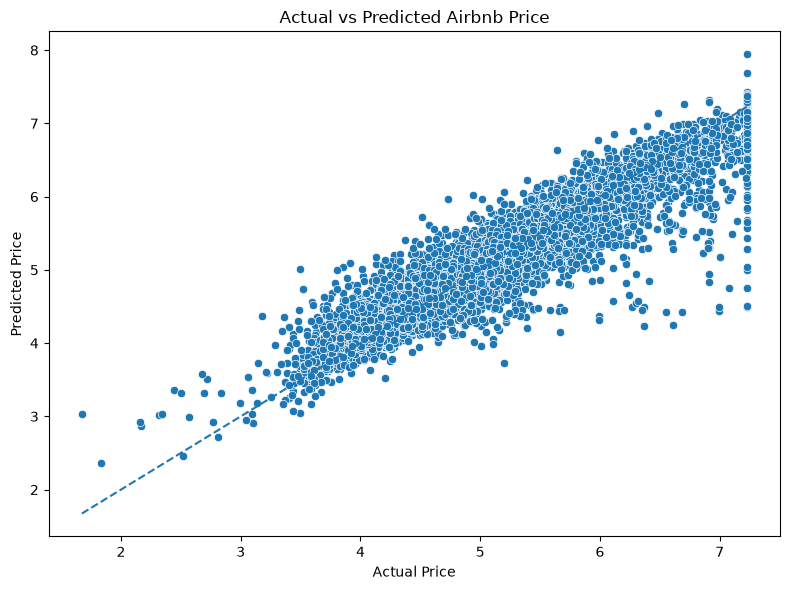

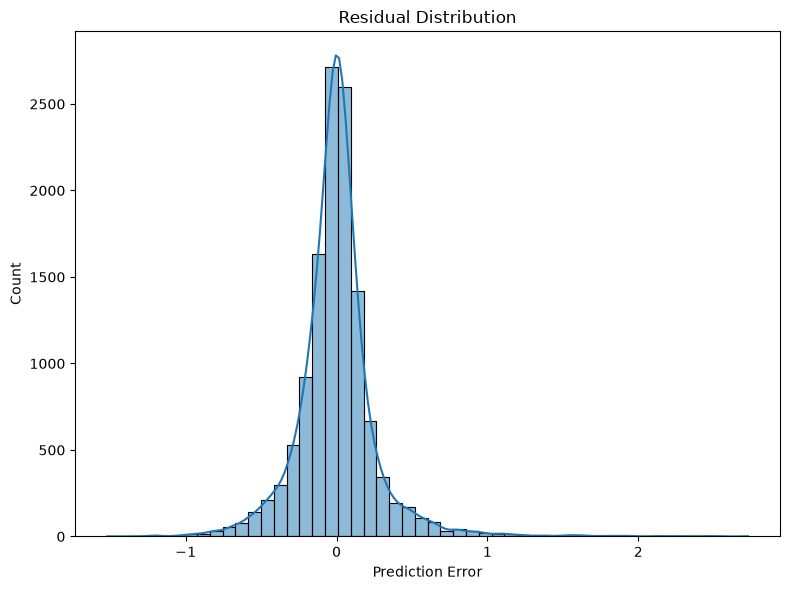

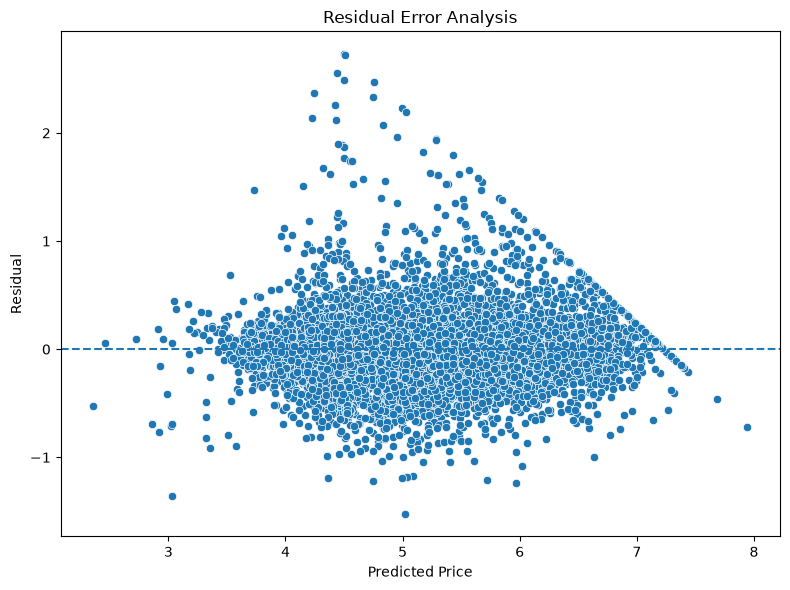


Error Statistics


,Mean Error,Mean Absolute Error,Maximum Error,Minimum Error
0,0.001043,0.169968,2.727218,-1.520109



Top 10 Worst Predictions


,Actual_Price,Predicted_Price,Error,Absolute_Error
2294,7.225814,4.498596,2.727218,2.727218
9913,7.225814,4.507673,2.718142,2.718142
2714,6.997340,4.439325,2.558015,2.558015
10158,6.990257,4.498700,2.491557,2.491557
5815,7.225814,4.757371,2.468444,2.468444
155,7.225814,4.757421,2.468394,2.468394
11719,6.610696,4.244365,2.366331,2.366331
11836,7.079184,4.747448,2.331737,2.331737
2454,6.684612,4.422033,2.262579,2.262579
696,7.225814,4.994719,2.231095,2.231095



Evaluation and Error Analysis Completed Successfully!


In [1]:


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# Load Test Data
# ============================================================


X_test = pd.read_csv(
    "../data/processed/X_test.csv"
)


y_test = pd.read_csv(
    "../data/processed/y_test.csv"
)


# Convert target dataframe to series

if isinstance(y_test, pd.DataFrame):
    y_test = y_test.iloc[:,0]


print("Test Feature Shape:")
print(X_test.shape)


print("\nTarget Shape:")
print(y_test.shape)



# ============================================================
# Load Trained Model
# ============================================================


model = joblib.load(
    "../models/tuned_gradient_boosting_model.pkl"
)


print("\nModel Loaded Successfully!")



# ============================================================
# Prediction
# ============================================================


y_pred = model.predict(
    X_test
)


print("\nPrediction Completed!")



# ============================================================
# Evaluation Metrics
# ============================================================


mae = mean_absolute_error(
    y_test,
    y_pred
)


rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)


r2 = r2_score(
    y_test,
    y_pred
)



results = pd.DataFrame({

    "Metric":[
        "MAE",
        "RMSE",
        "R2 Score"
    ],

    "Value":[
        mae,
        rmse,
        r2
    ]

})


print("\nModel Performance")
display(results)



# ============================================================
# Save Predictions
# ============================================================


prediction_results = pd.DataFrame({

    "Actual_Price": y_test,

    "Predicted_Price": y_pred,

    "Error":
    y_test - y_pred

})


prediction_results.to_csv(

    "../data/predictions.csv",

    index=False

)


print("\nPrediction file saved!")



# ============================================================
# Actual vs Predicted Plot
# ============================================================


plt.figure(
    figsize=(8,6)
)


sns.scatterplot(

    x=y_test,

    y=y_pred

)


plt.xlabel(
    "Actual Price"
)


plt.ylabel(
    "Predicted Price"
)


plt.title(
    "Actual vs Predicted Airbnb Price"
)


plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    linestyle="--"

)


plt.tight_layout()


plt.savefig(

    "../figures/actual_vs_predicted.png",

    dpi=300

)


plt.show()



# ============================================================
# Residual Analysis
# ============================================================


residuals = y_test - y_pred



plt.figure(

    figsize=(8,6)

)


sns.histplot(

    residuals,

    bins=50,

    kde=True

)


plt.xlabel(

    "Prediction Error"

)


plt.title(

    "Residual Distribution"

)


plt.tight_layout()


plt.savefig(

    "../figures/residual_distribution.png",

    dpi=300

)


plt.show()



# ============================================================
# Residual Scatter Plot
# ============================================================


plt.figure(

    figsize=(8,6)

)


sns.scatterplot(

    x=y_pred,

    y=residuals

)


plt.axhline(

    0,

    linestyle="--"

)


plt.xlabel(

    "Predicted Price"

)


plt.ylabel(

    "Residual"

)


plt.title(

    "Residual Error Analysis"

)


plt.tight_layout()


plt.savefig(

    "../figures/residual_error_analysis.png",

    dpi=300

)


plt.show()



# ============================================================
# Error Statistics
# ============================================================


error_analysis = pd.DataFrame({

    "Mean Error":
    [residuals.mean()],


    "Mean Absolute Error":
    [abs(residuals).mean()],


    "Maximum Error":
    [residuals.max()],


    "Minimum Error":
    [residuals.min()]

})


print("\nError Statistics")

display(error_analysis)



# ============================================================
# Worst Predictions
# ============================================================


worst_predictions = prediction_results.copy()


worst_predictions["Absolute_Error"] = abs(

    worst_predictions["Error"]

)


worst_predictions = worst_predictions.sort_values(

    by="Absolute_Error",

    ascending=False

)


print("\nTop 10 Worst Predictions")

display(

    worst_predictions.head(10)

)



print("\nEvaluation and Error Analysis Completed Successfully!")